## Pulse Shape Comparison: Leakage to Second Excited State

In this notebook, we compare the efficiency of different pulse shapes applied to a transmon qubit. The goal is to implement an $X$ gate that transfers population from $\lvert 0 \rangle$ to $\lvert 1 \rangle$ with minimal leakage to the second excited state $\lvert 2 \rangle$.

Due to the weak anharmonicity of transmon qubits, strong or fast pulses can unintentionally excite the $\lvert 1 \rangle \rightarrow \lvert 2 \rangle$ transition. To quantify the leakage, we track the population in the $\lvert 2 \rangle$ state after the pulse.

The Hamiltonian used includes three levels and a drive term, and the pulses we analyze include:

- **Gaussian**
- **Square**
- **DRAG**
- **Lorentzian**
- **Flat-top Gaussian**

The leakage is calculated as:

$
\text{Leakage} = |\langle 2 | \psi(t_{\text{final}}) \rangle|^2
$

We compare this value across different pulse shapes while maintaining the same pulse area and duration where appropriate.

This analysis helps evaluate how well a pulse isolates the computational subspace $\{ \lvert 0 \rangle, \lvert 1 \rangle \}$ and suppresses transitions to $\lvert 2 \rangle$.


--- Simulating a SHORT GAUSSIAN π-Pulse (for comparison) ---


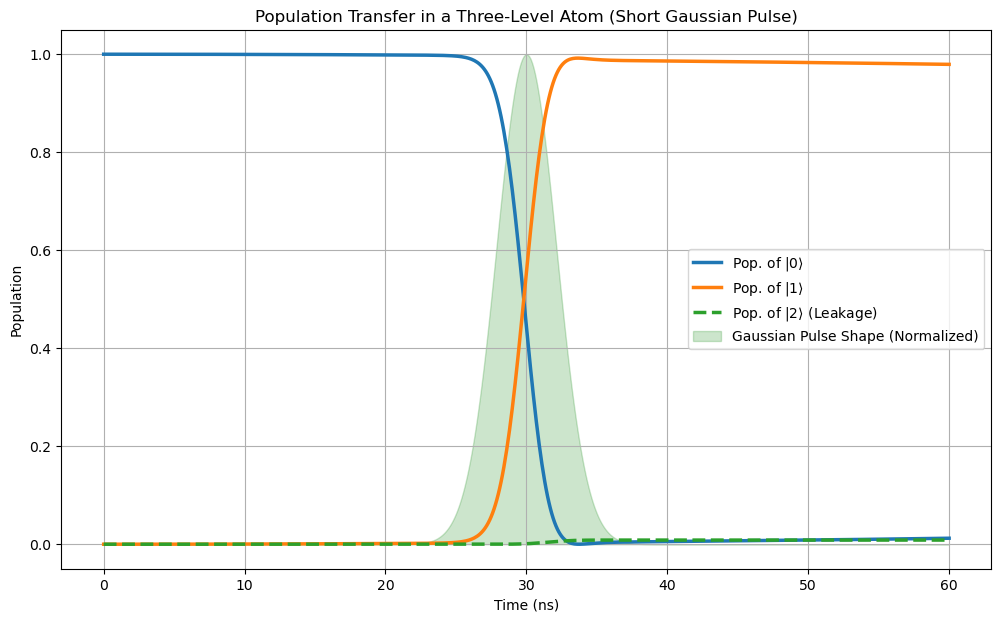

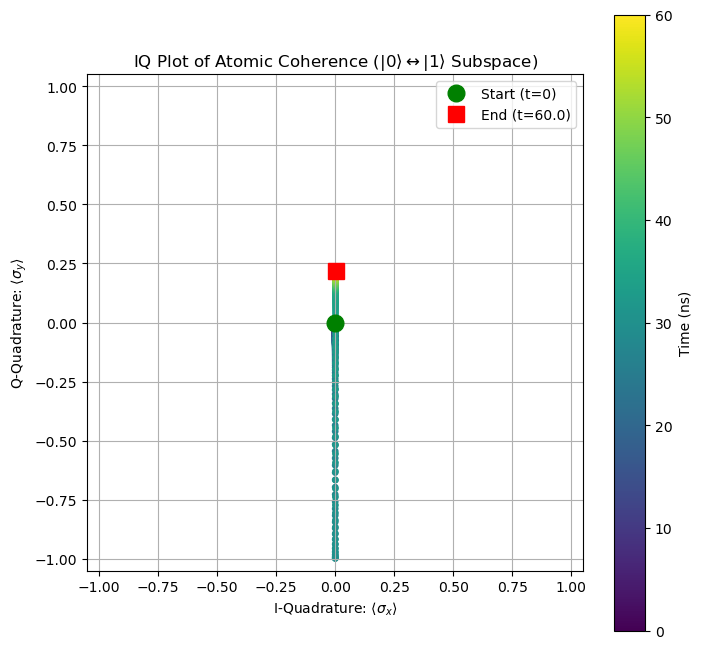


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 1.2% |0>, 97.9% |1>, 0.8% |2>


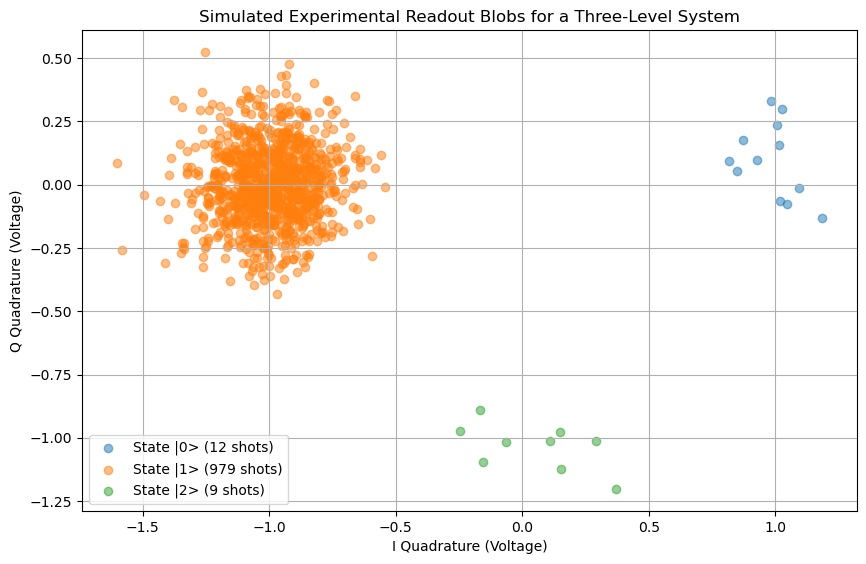

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (MODIFIED FOR 3 STATES)
# ==============================================================================
# <-- THIS ENTIRE FUNCTION HAS BEEN UPDATED FOR THREE STATES -->
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities of being in states
    |0>, |1>, or |2>.
    """
    # Renormalize to handle small numerical errors
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    # <-- MODIFIED: Print all three state populations
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>, {p2_final*100:.1f}% |2>")

    # <-- MODIFIED: Define centers for three blobs
    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0]) # Center for the |2> state

    # <-- MODIFIED: Calculate shots for all three states
    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    # Generate data for state |0> and |1>
    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)

    # <-- NEW: Generate data for state |2>
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    # <-- MODIFIED: Plot all three blobs
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)') # Plot for |2>
    ax.set_title("Simulated Experimental Readout Blobs for a Three-Level System")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()


# ==============================================================================
# SIMULATION WITH GAUSSIAN PULSE (USING SAME PARAMETERS AS LORENTZIAN)
# ==============================================================================
def simulate_gaussian_pulse_with_all_plots():
    """
    Demonstrates the behavior of a short GAUSSIAN pulse using the exact same
    Hamiltonian and parameters as the previous Lorentzian simulation for direct comparison.
    """
    print("--- Simulating a SHORT GAUSSIAN π-Pulse (for comparison) ---")

    # --- 1. SETUP: System parameters (EXACTLY THE SAME as the Lorentzian version) ---
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.1 * 2 * np.pi, 0.1 * 2 * np.pi, 0.0003 * 2 * np.pi

    # --- 2. Define Operators (UNCHANGED) ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))

    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))

    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))

    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Original, Unchanged Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())  # <<< NEWLY ADDED TER
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define the GAUSSIAN π-Pulse ---
    pulse_t0 = 30.0
    
    pulse_duration = 5.0
    pulse_sigma = pulse_duration / (2 * np.sqrt(2 * np.log(2)))
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    H_drive_01_op = sm_01 + sm_01.dag()
    H_drive_02_op = sm_ab2 + sm_ab2.dag()

    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t-args['t0'])**2 / (2*args['sigma']**2))
    
    unwanted_drive_amp_ratio = 0.1

    H_final = [H_static_quantum,
               [H_drive_01_op, gaussian_coeff],
               [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * gaussian_coeff(t, args)]
              ]

    # --- 5. Initial State and Simulation (UNCHANGED) ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 6. Data Extraction (UNCHANGED) ---
    pop_0, pop_1, pop_2 = result.expect[0], result.expect[1], result.expect[2]
    I_vals, Q_vals = result.expect[3], result.expect[4]

    # --- 7. Plotting (UNCHANGED) ---
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', linestyle='--')

    pulse_shape_norm = [gaussian_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape_norm, color='green', alpha=0.2, label='Gaussian Pulse Shape (Normalized)')

    ax_p.set_title("Population Transfer in a Three-Level Atom (Short Gaussian Pulse)")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # --- 8. IQ Plot and Readout Blobs (UNCHANGED) ---
    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence ($|0\rangle \leftrightarrow |1\rangle$ Subspace)")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()
    
    # ##########################################################################
    # ### THE ONLY OTHER CHANGE IS ON THE NEXT LINE ###
    # ##########################################################################
    generate_readout_blobs(pop_0[-1], pop_1[-1], pop_2[-1])


if __name__ == '__main__':
    simulate_gaussian_pulse_with_all_plots()

--- Simulating a π-Pulse with a COSINE Shape ---


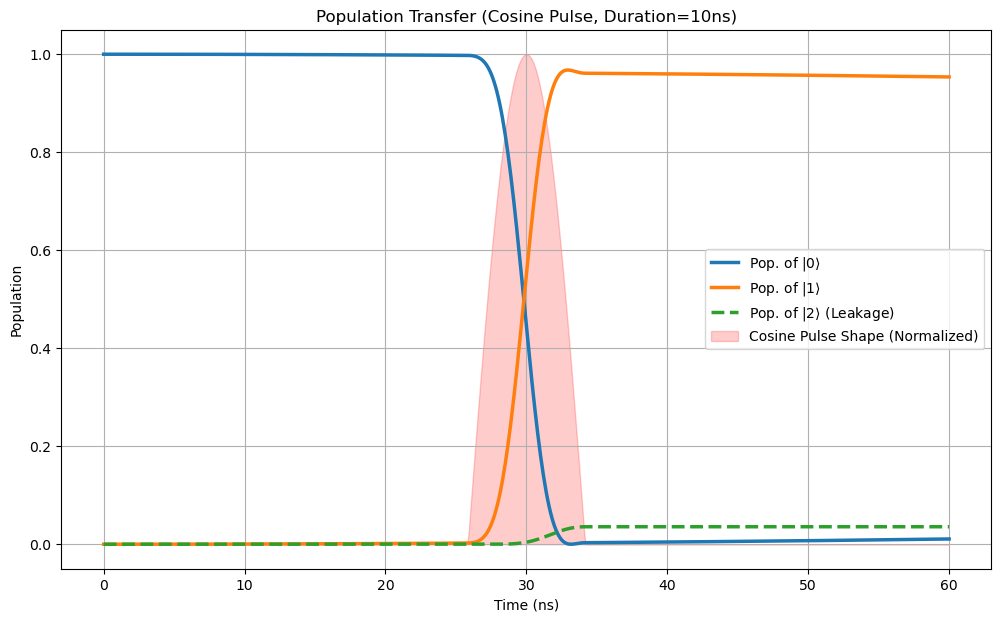

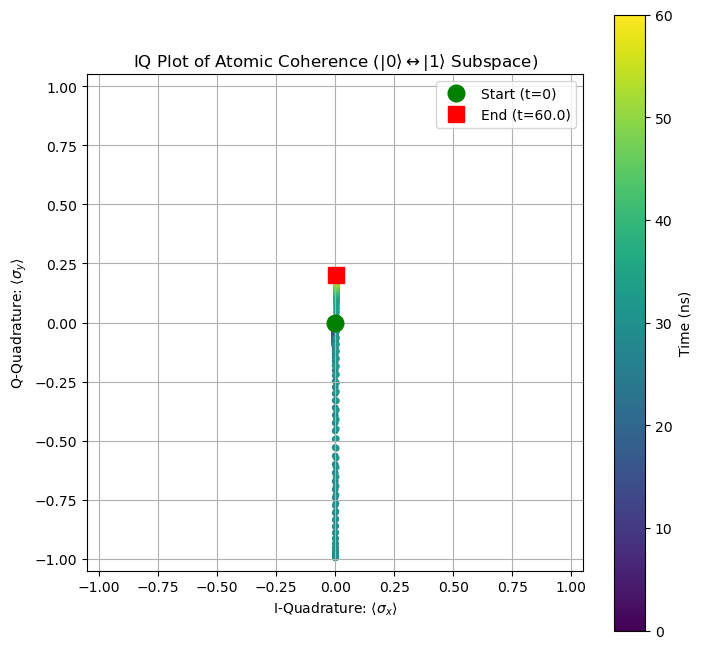


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 1.1% |0>, 95.4% |1>, 3.6% |2>


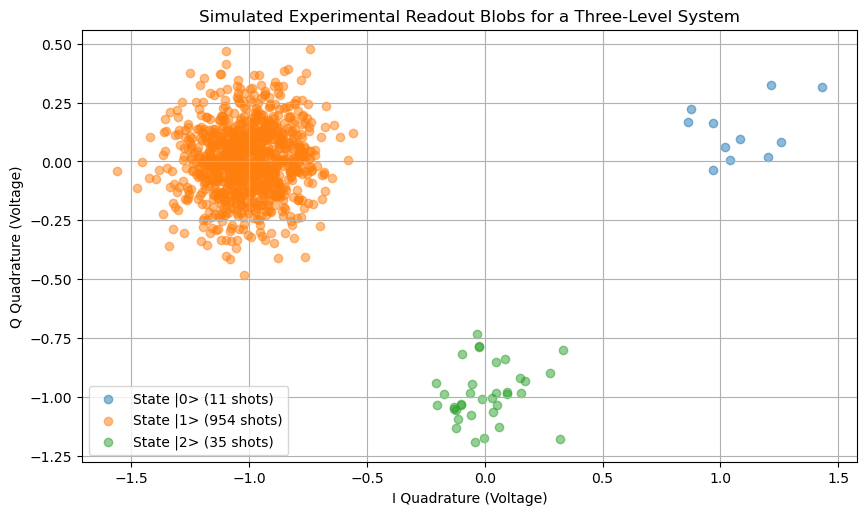

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (UNCHANGED)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities of being in states
    |0>, |1>, or |2>.
    """
    if not np.isclose(p0_final + p1_final + p2_final, 1.0):
        # Ensure total probability is close to 1, accounting for numerical precision
        total_prob = p0_final + p1_final + p2_final
        print(f"Warning: Probabilities sum to {total_prob:.6f}, not 1.0. Renormalizing.")
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>, {p2_final*100:.1f}% |2>")

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')

    ax.set_title("Simulated Experimental Readout Blobs for a Three-Level System")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# SIMULATION WITH COSINE PULSE
# ==============================================================================
def simulate_cosine_pulse():
    """
    Runs a simulation with a COSINE pulse of a fixed duration, using the
    original, unchanged Hamiltonian.
    """
    print("--- Simulating a π-Pulse with a COSINE Shape ---")

    # --- 1. SETUP: System parameters (UNCHANGED) ---
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.1 * 2 * np.pi, 0.1 * 2 * np.pi, 0.0003 * 2 * np.pi

    # --- 2. Define Operators (UNCHANGED) ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))

    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))

    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))

    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Original, Unchanged Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())  # <<< NEWLY ADDED TER
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define the COSINE π-Pulse ---
    pulse_t0 = 30.0
    pulse_duration_T = 8.33
    pulse_amplitude = (np.pi**2) / (4 * pulse_duration_T)
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'T': pulse_duration_T}

    def cosine_pulse_func(t, args):
        t_relative = t - args['t0']
        if abs(t_relative) < args['T'] / 2.0:
            return args['A'] * np.cos(np.pi * t_relative / args['T'])
        return 0.0

    H_drive_01_op = sm_01 + sm_01.dag()
    H_drive_02_op = sm_ab2 + sm_ab2.dag()
    unwanted_drive_amp_ratio = 0.2

    H_final = [H_static_quantum,
               [H_drive_01_op, cosine_pulse_func],
               [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * cosine_pulse_func(t, args)]]

    # --- 5. Initial State and Simulation ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops=[], e_ops=e_ops, args=drive_args)

    # --- 6. Data Extraction ---
    pop_0, pop_1, pop_2 = result.expect[0], result.expect[1], result.expect[2]
    I_vals, Q_vals = result.expect[3], result.expect[4]

    # --- 7. Plotting ---
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', linestyle='--')

    pulse_shape_norm = [cosine_pulse_func(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape_norm, color='red', alpha=0.2, label='Cosine Pulse Shape (Normalized)')
    ax_p.set_title("Population Transfer (Cosine Pulse, Duration=10ns)")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # --- 8. IQ Plot and Readout Blobs ---
    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence ($|0\rangle \leftrightarrow |1\rangle$ Subspace)")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', 'box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    # ##########################################################################
    # ### THE ONLY CHANGE IS ON THE NEXT LINE ###
    # ##########################################################################
    generate_readout_blobs(pop_0[-1], pop_1[-1], pop_2[-1])


# This part of your code seems incomplete, so I will comment it out
# to prevent errors. You can un-comment it when it's ready.
#
# def optimized_gaussian_drag():
#     # System parameters
#     anharmonicity = w2 - 2*w1 + w0  # Your actual system value
#     optimal_alpha = -1/(2*anharmonicity)  # Theoretical starting point
#
#     # Pulse parameters
#     gate_time = 20  # Extended duration
#     sigma = gate_time/6
#     t_center = gate_time/2
#     pulse_amplitude = np.pi/(np.sqrt(2*np.pi)*sigma) * (1 + optimal_alpha**2/(4*sigma**2))
#
#     def I(t):
#         return pulse_amplitude * np.exp(-(t-t_center)**2/(2*sigma**2))
#
#     def Q(t):
#         return optimal_alpha * (-(t-t_center)/sigma**2) * I(t)
#
#     # Run simulation with these pulses

if __name__ == '__main__':
    simulate_cosine_pulse()

--- Simulating a SHORT π-Pulse to induce leakage (Original Hamiltonian) ---


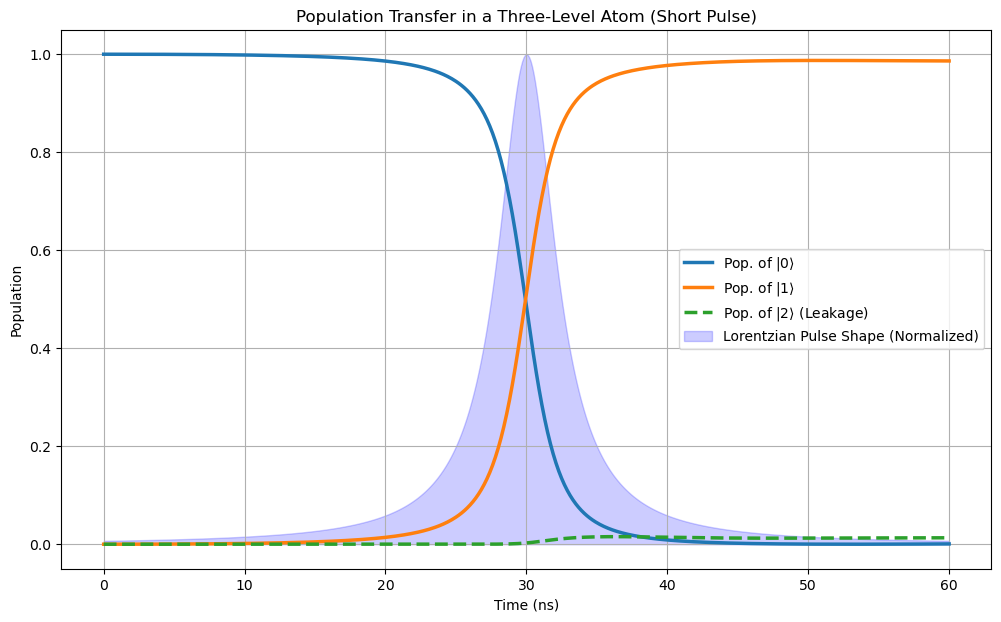

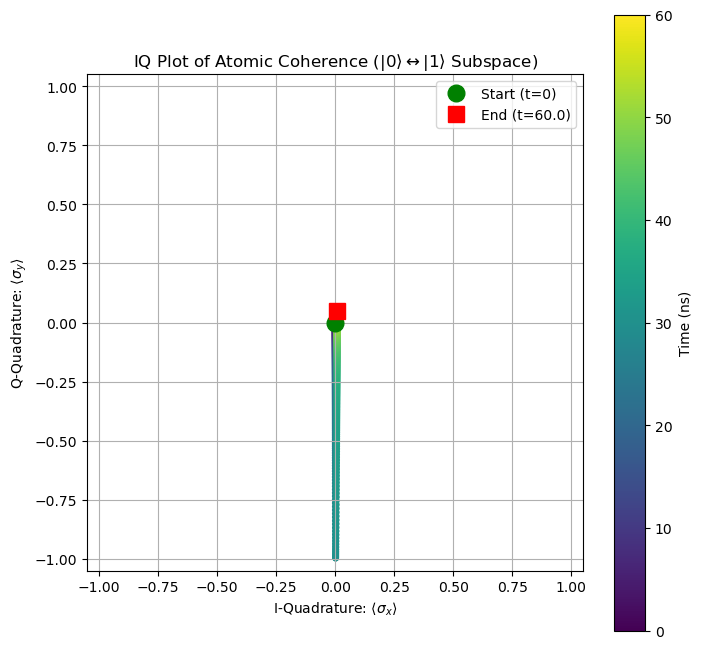


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 0.1% |0>, 98.6% |1>, 1.3% |2>


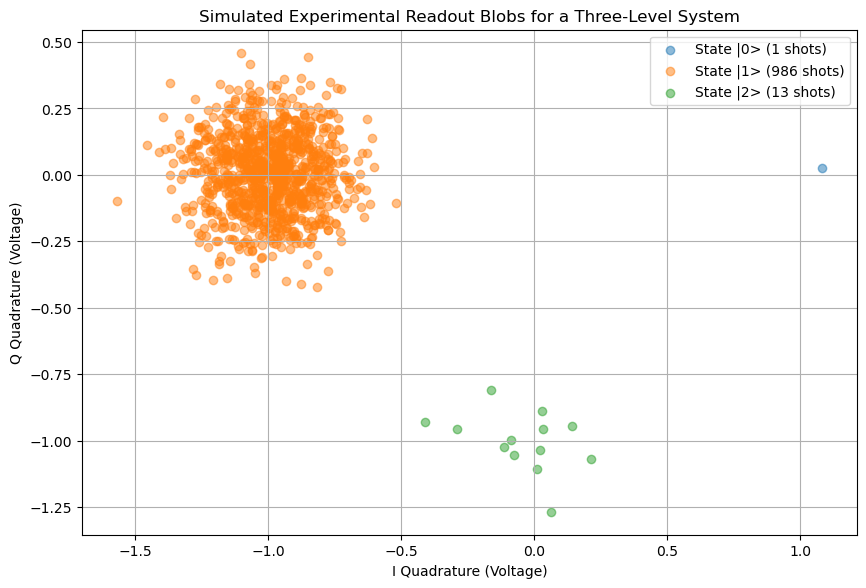

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (MODIFIED FOR 3 STATES)
# ==============================================================================
# <-- THIS ENTIRE FUNCTION HAS BEEN UPDATED FOR THREE STATES -->
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout for a three-level system by generating
    noisy data points based on the final probabilities of being in states
    |0>, |1>, or |2>.
    """
    # Renormalize to handle small numerical errors
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    # <-- MODIFIED: Print all three state populations
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>, {p2_final*100:.1f}% |2>")

    # <-- MODIFIED: Define centers for three blobs
    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0]) # Center for the |2> state

    # <-- MODIFIED: Calculate shots for all three states
    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    # Generate data for state |0> and |1>
    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)

    # <-- NEW: Generate data for state |2>
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    # <-- MODIFIED: Plot all three blobs
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)') # Plot for |2>
    ax.set_title("Simulated Experimental Readout Blobs for a Three-Level System")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()


# ==============================================================================
# SIMULATION WITH ORIGINAL HAMILTONIAN, TUNED FOR VISIBLE LEAKAGE
# ==============================================================================
def simulate_lorentzian_pulse_with_all_plots():
    """
    Demonstrates leakage caused by a short pulse duration using the original
    Hamiltonian. Parameters are tuned to make leakage visible.
    """
    print("--- Simulating a SHORT π-Pulse to induce leakage (Original Hamiltonian) ---")

    # --- 1. SETUP: System parameters (UNCHANGED) ---
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.1 * 2 * np.pi, 0.1 * 2 * np.pi, 0.0003 * 2 * np.pi

    # --- 2. Define Operators (UNCHANGED) ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))

    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))

    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))

    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Original, Unchanged Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())  # <<< NEWLY ADDED TER
    H_static_quantum = H_atom + H_fields + H_interaction
    # --- 4. Define the LORENTZIAN π-Pulse (UNCHANGED) ---
    pulse_t0 = 30.0
    pulse_gamma = 5
    pulse_amplitude = 1.0 / pulse_gamma

    H_drive_01_op = sm_01 + sm_01.dag()
    H_drive_02_op = sm_ab2 + sm_ab2.dag()

    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'gamma': pulse_gamma}
    lorentzian_coeff = lambda t, args: args['A'] * (args['gamma']/2)**2 / ((t - args['t0'])**2 + (args['gamma']/2)**2)
    
    unwanted_drive_amp_ratio = 0.2

    H_final = [H_static_quantum,
               [H_drive_01_op, lorentzian_coeff],
               [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * lorentzian_coeff(t, args)]
              ]

    # --- 5. Initial State and Simulation (UNCHANGED) ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 6. Data Extraction (UNCHANGED) ---
    pop_0, pop_1, pop_2 = result.expect[0], result.expect[1], result.expect[2]
    I_vals, Q_vals = result.expect[3], result.expect[4]

    # --- 7. Plotting (UNCHANGED) ---
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', linestyle='--')

    pulse_shape_norm = [lorentzian_coeff(t, drive_args) / pulse_amplitude for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape_norm, color='blue', alpha=0.2, label='Lorentzian Pulse Shape (Normalized)')

    ax_p.set_title("Population Transfer in a Three-Level Atom (Short Pulse)")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # --- 8. IQ Plot and Readout Blobs (UNCHANGED) ---
    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence ($|0\rangle \leftrightarrow |1\rangle$ Subspace)")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    # ##########################################################################
    # ### THE ONLY OTHER CHANGE IS ON THE NEXT LINE ###
    # ##########################################################################
    generate_readout_blobs(pop_0[-1], pop_1[-1], pop_2[-1])


if __name__ == '__main__':
    simulate_lorentzian_pulse_with_all_plots()

Optimizing DRAG alpha parameter...

Optimal alpha found: -0.0080
Minimum cost value: 0.0723
--- Simulating with alpha = -0.0080 ---


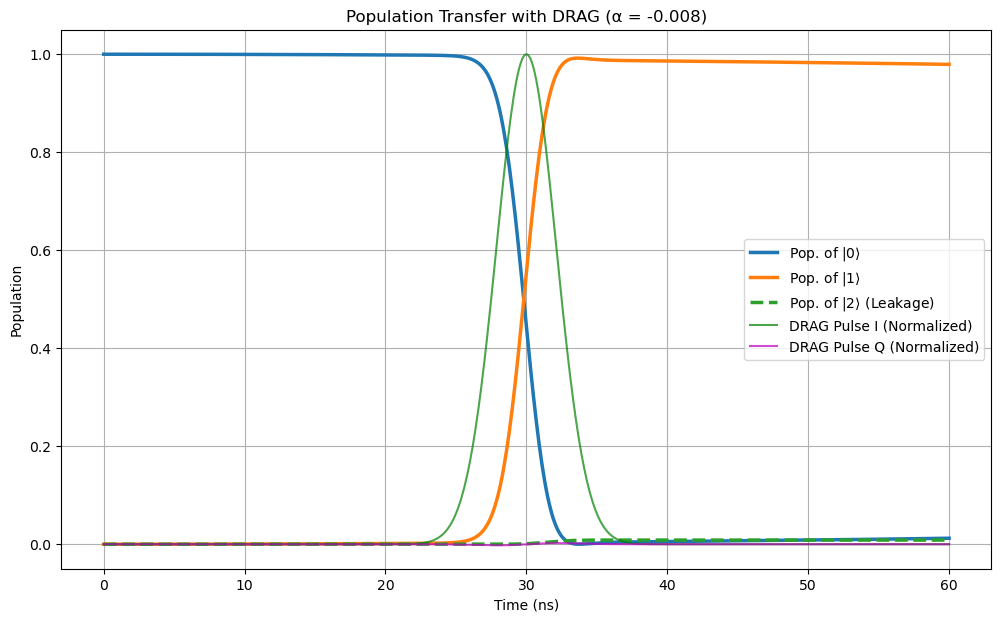

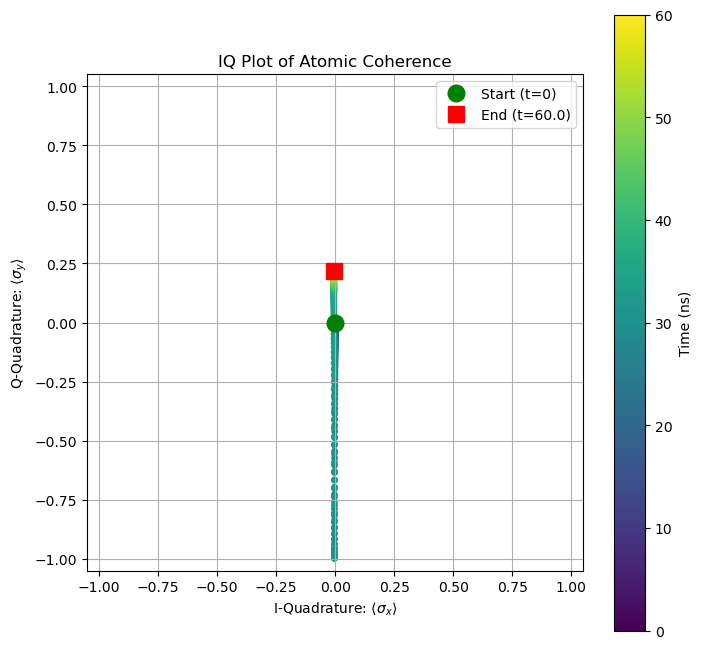


Final State: 1.2% |0>, 97.9% |1>, 0.8% |2>


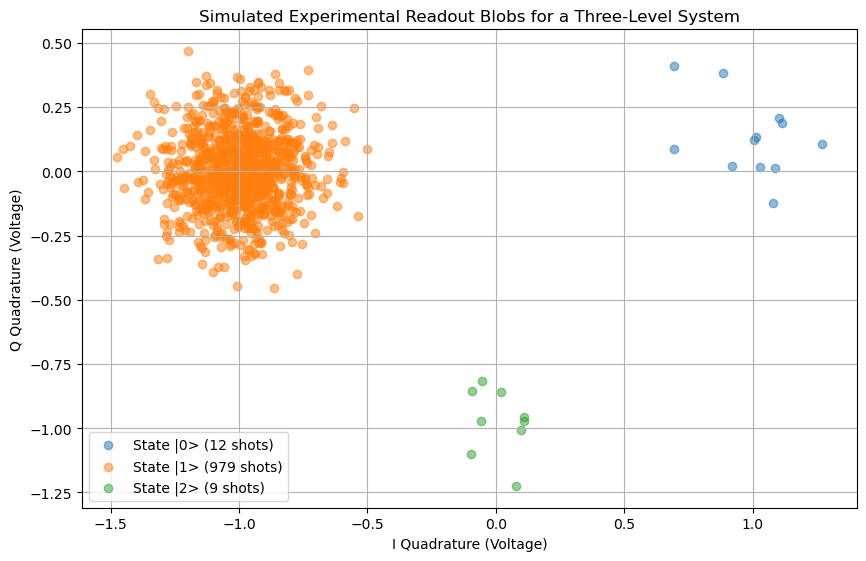

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
from scipy.optimize import minimize_scalar

# ==============================================================================
# EXPERIMENTAL READOUT PLOT FUNCTION (MODIFIED FOR 3 STATES)
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, p2_final, num_shots=1000, noise_level=0.15):
    """Simulates an experimental IQ readout for a three-level system."""
    total_prob = p0_final + p1_final + p2_final
    if not np.isclose(total_prob, 1.0):
        p0_final /= total_prob
        p1_final /= total_prob
        p2_final /= total_prob

    print(f"\nFinal State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>, {p2_final*100:.1f}% |2>")

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    center_2 = np.array([0.0, -1.0])

    num_shots_0 = int(np.round(p0_final * num_shots))
    num_shots_1 = int(np.round(p1_final * num_shots))
    num_shots_2 = num_shots - num_shots_0 - num_shots_1

    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)
    blob_2_I = np.random.normal(loc=center_2[0], scale=noise_level, size=num_shots_2)
    blob_2_Q = np.random.normal(loc=center_2[1], scale=noise_level, size=num_shots_2)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label=f'State |0> ({num_shots_0} shots)')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label=f'State |1> ({num_shots_1} shots)')
    ax.scatter(blob_2_I, blob_2_Q, alpha=0.5, label=f'State |2> ({num_shots_2} shots)')
    ax.set_title("Simulated Experimental Readout Blobs for a Three-Level System")
    ax.set_xlabel("I Quadrature (Voltage)"), ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True), ax.legend(), ax.set_aspect('equal', adjustable='box')
    plt.show()

# ==============================================================================
# OPTIMIZATION AND SIMULATION FUNCTIONS
# ==============================================================================
def cost_function(alpha, N_atom=3, N_field=4):
    """Calculate the cost for a given alpha parameter."""
    # System parameters
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.1 * 2 * np.pi, 0.1 * 2 * np.pi, 0.0003 * 2 * np.pi

    # --- 2. Define Operators (UNCHANGED) ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))

    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))

    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))

    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Original, Unchanged Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())  # <<< NEWLY ADDED TER
    H_static_quantum = H_atom + H_fields + H_interaction
    # DRAG Gaussian pulse parameters
    pulse_t0 = 30.0
    pulse_duration = 3.0
    pulse_sigma = pulse_duration / (2 * np.sqrt(2 * np.log(2)))
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    def gaussian_coeff(t, args):
        return args['A'] * np.exp(-(t-args['t0'])**2 / (2*args['sigma']**2))
    
    def dgaussian_coeff(t, args):
        g = gaussian_coeff(t, args)
        return - (t-args['t0'])/args['sigma']**2 * g
    
    def drag_coeff(t, args):
        return args['alpha'] * dgaussian_coeff(t, args)

    H_drive_01_op = sm_01 + sm_01.dag()
    H_drive_01_op_Q = -1j * (sm_01 - sm_01.dag())
    H_drive_02_op = sm_ab2 + sm_ab2.dag()

    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma, 'alpha': alpha}
    unwanted_drive_amp_ratio = 0.1

    H_final = [
        H_static_quantum,
        [H_drive_01_op, gaussian_coeff],
        [H_drive_01_op_Q, drag_coeff],
        [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * gaussian_coeff(t, args)]
    ]

    # Simulation
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # Final populations
    pop_0_final = result.expect[0][-1]
    pop_1_final = result.expect[1][-1]
    pop_2_final = result.expect[2][-1]
    
    # Cost function: minimize leakage and maximize |0> to |1> transfer
    cost = (1 - pop_1_final) + 5 * pop_2_final  # Weight leakage more heavily
    
    return cost

def optimize_alpha():
    """Find the optimal alpha parameter for DRAG pulse."""
    print("Optimizing DRAG alpha parameter...")
    
    # Search in a reasonable range for alpha
    result = minimize_scalar(cost_function, bounds=(-1.0, 1.0), method='bounded')
    
    optimal_alpha = result.x
    min_cost = result.fun
    
    print(f"\nOptimal alpha found: {optimal_alpha:.4f}")
    print(f"Minimum cost value: {min_cost:.4f}")
    
    return optimal_alpha

def simulate_gaussian_pulse_with_all_plots(alpha):
    """Run simulation with specified alpha parameter."""
    print(f"--- Simulating with alpha = {alpha:.4f} ---")

    # System parameters
    N_atom = 3
    N_field = 4
    w_b1 = 5.0 * 2 * np.pi
    w_b2 = 5.0 * 2 * np.pi
    w_a = 5.05 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2, g_12 = 0.1 * 2 * np.pi, 0.1 * 2 * np.pi, 0.0003 * 2 * np.pi

    # --- 2. Define Operators (UNCHANGED) ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_ab2_bare = basis(N_atom, 1) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    sm02_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm02 = tensor(sm02_bare, qeye(N_field), qeye(N_field))

    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_ab2 = tensor(sm_ab2_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))

    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))

    I_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    Q_op = tensor(-1j * sm_01_bare + 1j * sm_01_bare.dag(), qeye(N_field), qeye(N_field))

    # --- 3. Construct the Original, Unchanged Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) + \
                    lambda2 * (a2.dag() * sm_ab2 + a2 * sm_ab2.dag())  + \
                    g_12 * (sm_01 + sm_01.dag())  # <<< NEWLY ADDED TER
    H_static_quantum = H_atom + H_fields + H_interaction

    # DRAG Gaussian pulse parameters
    pulse_t0 = 30.0
    pulse_duration = 5.0
    pulse_sigma = pulse_duration / (2 * np.sqrt(2 * np.log(2)))
    required_area = np.pi / 2.0
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))

    def gaussian_coeff(t, args):
        return args['A'] * np.exp(-(t-args['t0'])**2 / (2*args['sigma']**2))
    
    def dgaussian_coeff(t, args):
        g = gaussian_coeff(t, args)
        return - (t-args['t0'])/args['sigma']**2 * g
    
    def drag_coeff(t, args):
        return args['alpha'] * dgaussian_coeff(t, args)

    H_drive_01_op = sm_01 + sm_01.dag()
    H_drive_01_op_Q = -1j * (sm_01 - sm_01.dag())
    H_drive_02_op = sm_ab2 + sm_ab2.dag()

    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma, 'alpha': alpha}
    unwanted_drive_amp_ratio = 0.1

    H_final = [
        H_static_quantum,
        [H_drive_01_op, gaussian_coeff],
        [H_drive_01_op_Q, drag_coeff],
        [H_drive_02_op, lambda t, args: unwanted_drive_amp_ratio * gaussian_coeff(t, args)]
    ]

    # Simulation
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # Data extraction
    pop_0, pop_1, pop_2 = result.expect[0], result.expect[1], result.expect[2]
    I_vals, Q_vals = result.expect[3], result.expect[4]

    # Plotting
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', linestyle='--')

    pulse_I = [gaussian_coeff(t, drive_args) for t in tlist]
    pulse_Q = [drag_coeff(t, drive_args) for t in tlist]
    ax_p.plot(tlist, np.array(pulse_I)/pulse_amplitude, 'g-', alpha=0.7, label='DRAG Pulse I (Normalized)')
    ax_p.plot(tlist, np.array(pulse_Q)/pulse_amplitude, 'm-', alpha=0.7, label='DRAG Pulse Q (Normalized)')
    
    ax_p.set_title(f"Population Transfer with DRAG (α = {alpha:.3f})")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    # IQ Plot
    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    # Readout blobs
    generate_readout_blobs(pop_0[-1], pop_1[-1], pop_2[-1])

def main():
    """Main execution function."""
    optimal_alpha = optimize_alpha()
    simulate_gaussian_pulse_with_all_plots(alpha=optimal_alpha)

if __name__ == '__main__':
    main()